In [1]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('netflix_titles.csv')

# See first 5 rows
print("First 5 rows:")
print(df.head())

# Check shape (rows, columns)
print("\nShape (rows, columns):", df.shape)

# Check column names
print("\nColumn Names:", df.columns.tolist())

# Check missing values
print("\nMissing Values in each column:")
print(df.isnull().sum())

First 5 rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24

This dataset contains information about Netflix Movies and TV Shows available on the platform. It has 8807 rows and 12 columns. Key columns include title, type, country, release year, rating, and listed_in (genres). Some columns like director (2634 missing), cast (825 missing), and country have missing values. The data covers content added to Netflix from 2008 to 2021.

In [3]:
# Fill missing values
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)

# Drop rows where date_added is missing
df.dropna(subset=['date_added'], inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Extract year from date_added column
df['year_added'] = pd.to_datetime(df['date_added'].str.strip()).dt.year

# Confirm cleaning worked
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nNew shape:", df.shape)
print("\nCleaning done successfully! ✅")

Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
year_added      0
dtype: int64

New shape: (8797, 13)

Cleaning done successfully! ✅


/tmp/ipykernel_1850/3374749605.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
/tmp/ipykernel_1850/3374749605.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [4]:
# Question 1: How many Movies vs TV Shows?
print("Q1: Movies vs TV Shows count:")
print(df['type'].value_counts())

print("\n" + "="*50)

# Question 2: Which country produces the most content?
print("Q2: Top 10 countries by content:")
print(df['country'].value_counts().head(10))

print("\n" + "="*50)

# Question 3: What are the most common ratings?
print("Q3: Most common content ratings:")
print(df['rating'].value_counts())

print("\n" + "="*50)

# Question 4: How many titles were added each year?
print("Q4: Titles added per year:")
print(df['year_added'].value_counts().sort_index())

print("\n" + "="*50)

# Question 5: What are the most popular genres?
print("Q5: Top 10 most popular genres:")
print(df['listed_in'].value_counts().head(10))

Q1: Movies vs TV Shows count:
type
Movie      6131
TV Show    2666
Name: count, dtype: int64

Q2: Top 10 countries by content:
country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

Q3: Most common content ratings:
rating
TV-MA       3209
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

Q4: Titles added per year:
year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

Q5: T

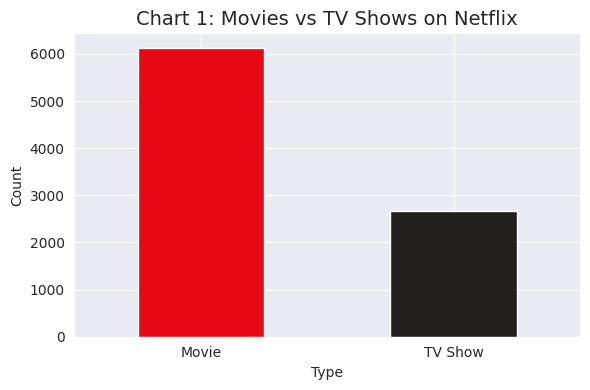

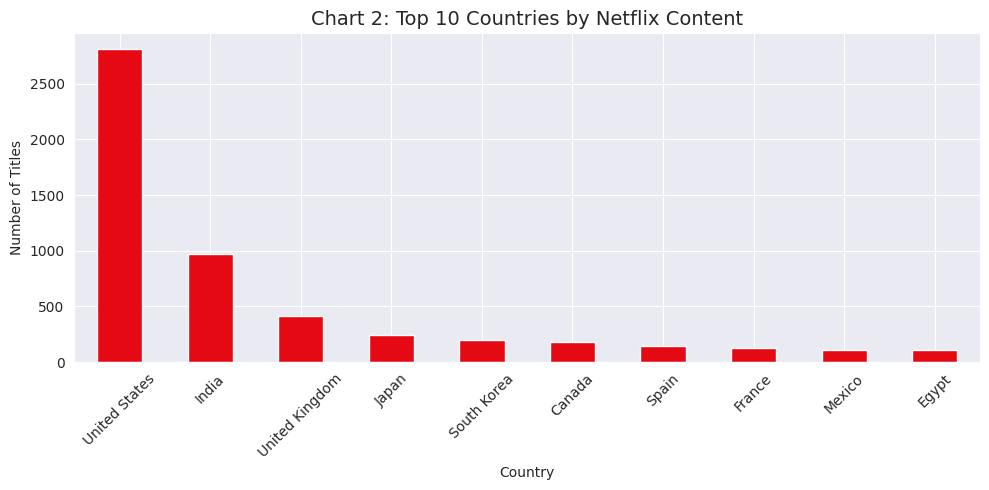

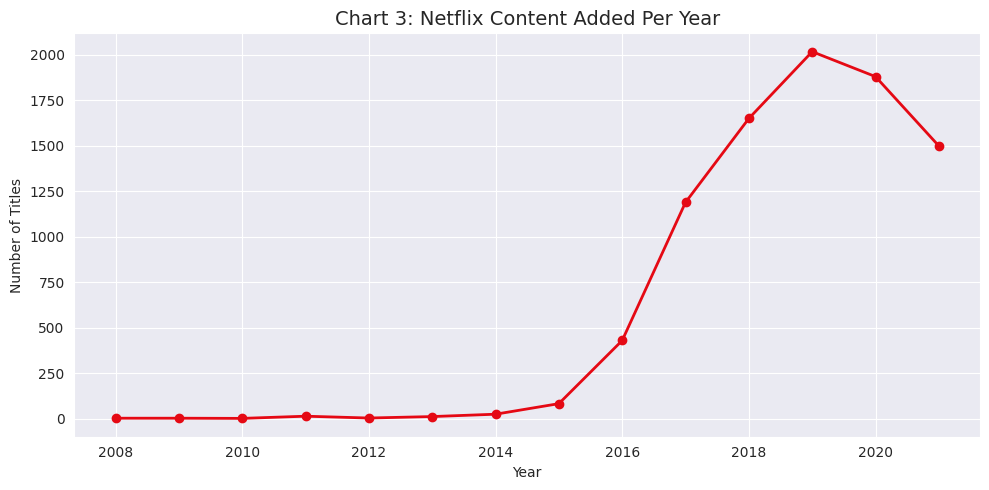

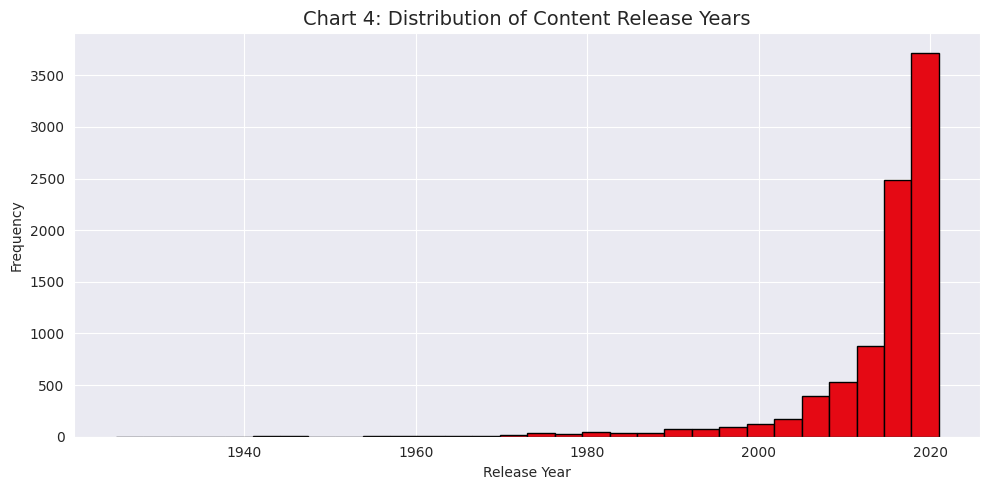

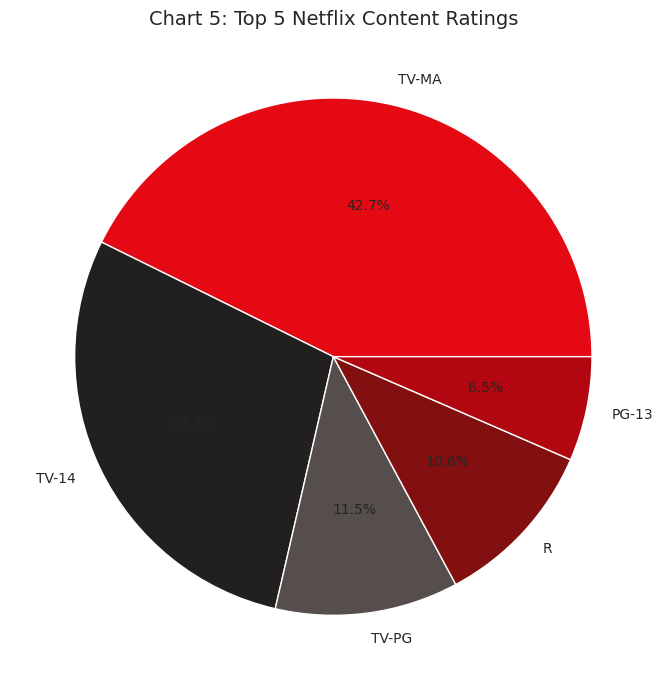

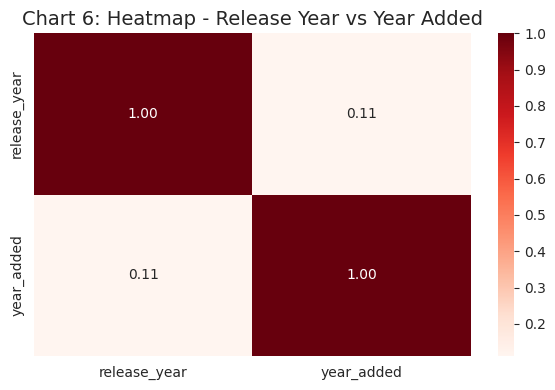

All 6 charts created successfully! ✅


In [5]:
# Set style for all charts
sns.set_style("darkgrid")

# ── CHART 1: Bar Chart - Movies vs TV Shows ──
plt.figure(figsize=(6,4))
df['type'].value_counts().plot(kind='bar', color=['#E50914','#221F1F'])
plt.title('Chart 1: Movies vs TV Shows on Netflix', fontsize=14)
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ── CHART 2: Bar Chart - Top 10 Countries ──
plt.figure(figsize=(10,5))
df[df['country'] != 'Unknown']['country'].value_counts().head(10).plot(kind='bar', color='#E50914')
plt.title('Chart 2: Top 10 Countries by Netflix Content', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ── CHART 3: Line Chart - Content Added Per Year ──
plt.figure(figsize=(10,5))
df['year_added'].value_counts().sort_index().plot(kind='line', marker='o', color='#E50914', linewidth=2)
plt.title('Chart 3: Netflix Content Added Per Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

# ── CHART 4: Histogram - Release Year Distribution ──
plt.figure(figsize=(10,5))
df['release_year'].plot(kind='hist', bins=30, color='#E50914', edgecolor='black')
plt.title('Chart 4: Distribution of Content Release Years', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# ── CHART 5: Pie Chart - Top 5 Ratings ──
plt.figure(figsize=(7,7))
df['rating'].value_counts().head(5).plot(kind='pie', autopct='%1.1f%%',
colors=['#E50914','#221F1F','#564d4d','#831010','#b20710'])
plt.title('Chart 5: Top 5 Netflix Content Ratings', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.show()

# ── CHART 6: Heatmap - Correlation of Numeric Columns ──
plt.figure(figsize=(6,4))
numeric_df = df[['release_year', 'year_added']].dropna()
sns.heatmap(numeric_df.corr(), annot=True, cmap='Reds', fmt='.2f')
plt.title('Chart 6: Heatmap - Release Year vs Year Added', fontsize=14)
plt.tight_layout()
plt.show()

print("All 6 charts created successfully! ✅")

Insight 1: Movies make up 70% (6131) of Netflix content vs only 30% TV Shows (2666), showing Netflix primarily focuses on films over series (Chart 1).
Insight 2: The United States dominates with 2812 titles, followed by India with 972 — together they account for nearly half of all Netflix content globally (Chart 2).
Insight 3: Netflix grew explosively after 2015, peaking at 2016 titles added in 2019 — this shows Netflix's aggressive content expansion strategy between 2016-2020 (Chart 3).
Insight 4: Most content on Netflix was released after 2000, with peak releases around 2017-2020, showing Netflix strongly prefers recent productions over classic/old content (Chart 4).
Insight 5: TV-MA rating dominates at 42.7%, meaning Netflix primarily targets adult audiences — content for children and families (TV-Y, TV-G, TV-PG) is a minority (Chart 5).

Most Surprising Finding:
The finding that surprised me most was that India is the second largest content producer on Netflix with 972 titles, almost matching the dominance of the United States. This shows how important the Indian market is for Netflix's global strategy.